Shape: (234, 17)


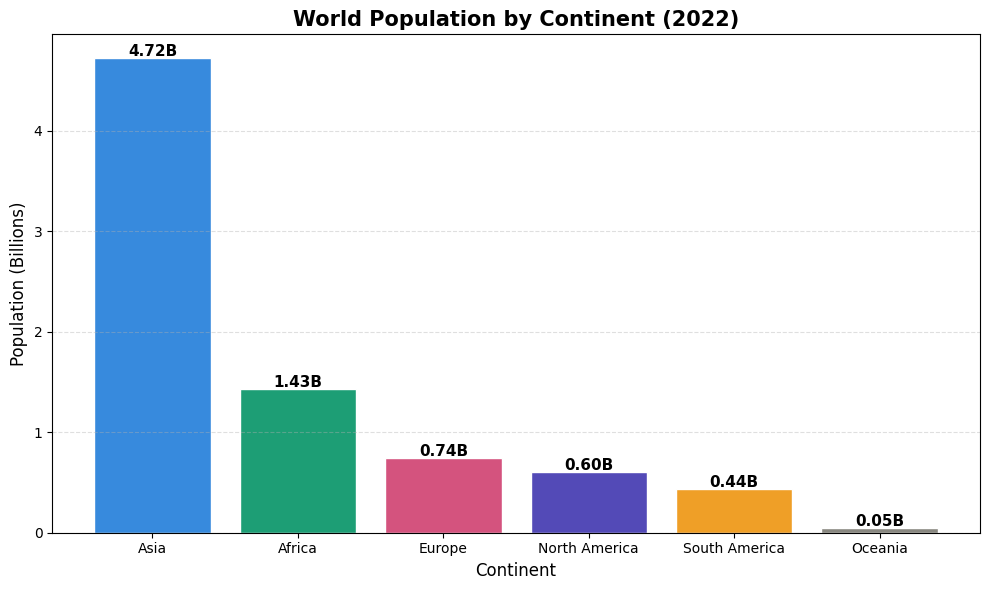

Plot 1 saved!


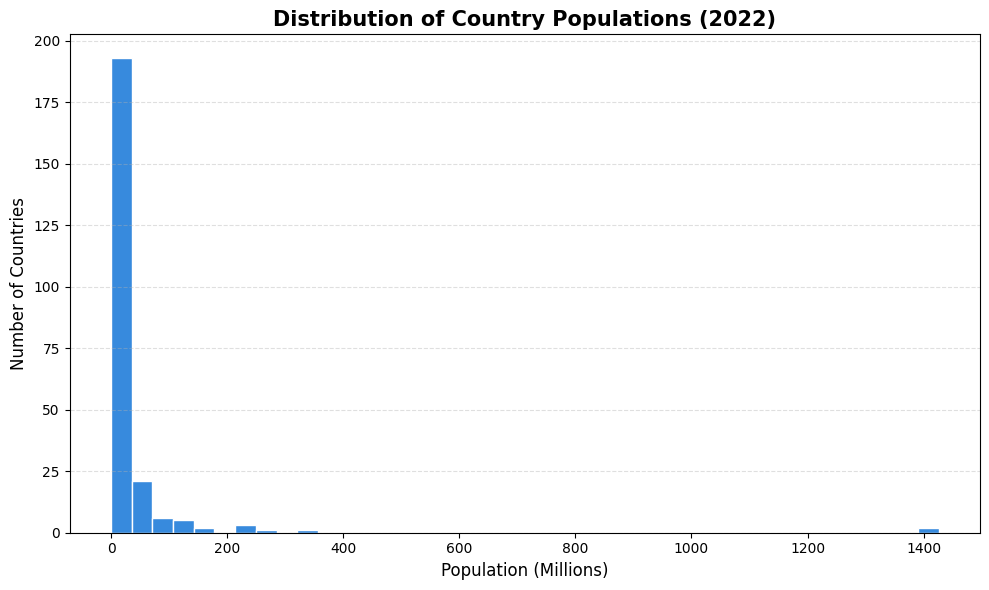

Plot 2 saved!


C:\Users\JAI AKASH P\AppData\Local\Temp\ipykernel_9560\1625324090.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x="Country/Territory", y="Pop (M)", palette="Blues_d")


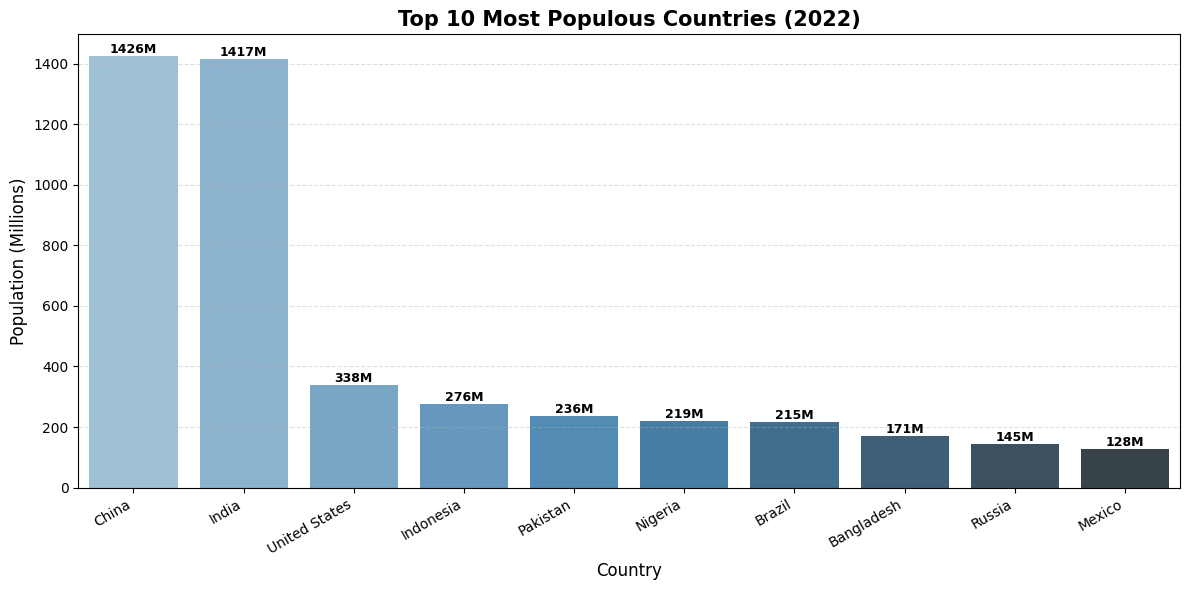

Plot 3 saved!


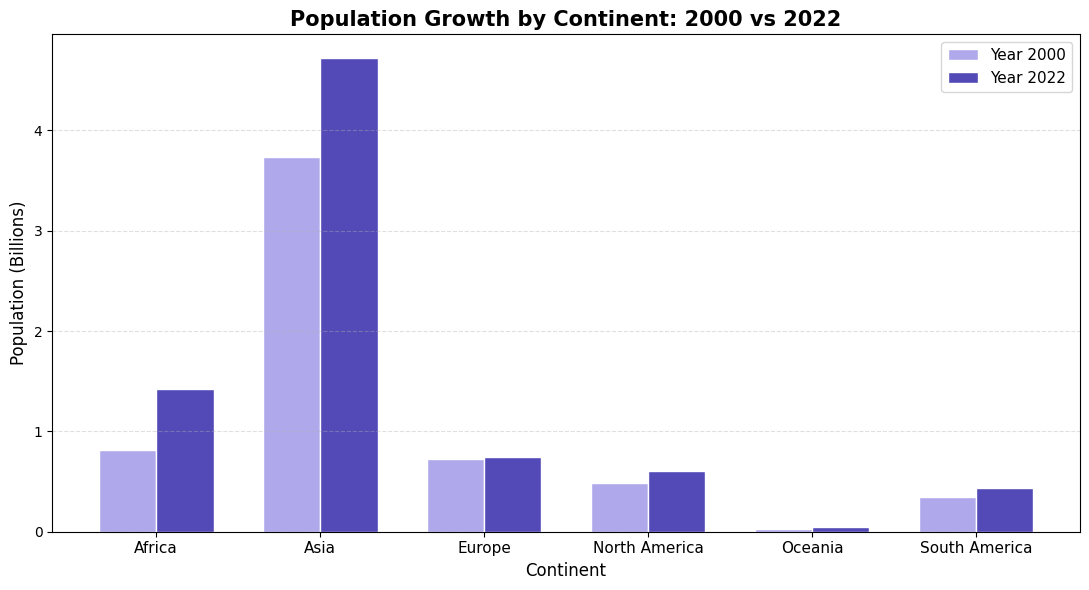

Plot 4 saved!

All 4 plots saved in C:\prodigy_task1\


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load Data
df = pd.read_csv(r"C:\prodigy_task1\archive\world_population.csv")
print("Shape:", df.shape)

# Plot 1: Bar Chart - Population by Continent
continent_pop = df.groupby("Continent")["2022 Population"].sum().sort_values(ascending=False).reset_index()
continent_pop["Population (B)"] = continent_pop["2022 Population"] / 1e9

plt.figure(figsize=(10, 6))
colors = ["#378ADD", "#1D9E75", "#D4537E", "#534AB7", "#EF9F27", "#888780"]
bars = plt.bar(continent_pop["Continent"], continent_pop["Population (B)"], color=colors, edgecolor="white")
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 0.02, f"{h:.2f}B", ha="center", fontsize=11, fontweight="bold")
plt.title("World Population by Continent (2022)", fontsize=15, fontweight="bold")
plt.xlabel("Continent", fontsize=12)
plt.ylabel("Population (Billions)", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(r"C:\prodigy_task1\plot1_continent_bar.png", dpi=150)
plt.show()
print("Plot 1 saved!")

# Plot 2: Histogram - Country Population Distribution
plt.figure(figsize=(10, 6))
plt.hist(df["2022 Population"] / 1e6, bins=40, color="#378ADD", edgecolor="white")
plt.title("Distribution of Country Populations (2022)", fontsize=15, fontweight="bold")
plt.xlabel("Population (Millions)", fontsize=12)
plt.ylabel("Number of Countries", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(r"C:\prodigy_task1\plot2_histogram.png", dpi=150)
plt.show()
print("Plot 2 saved!")

# Plot 3: Top 10 Most Populous Countries
top10 = df.nlargest(10, "2022 Population")[["Country/Territory", "2022 Population"]].copy()
top10["Pop (M)"] = top10["2022 Population"] / 1e6
plt.figure(figsize=(12, 6))
sns.barplot(data=top10, x="Country/Territory", y="Pop (M)", palette="Blues_d")
for i, val in enumerate(top10["Pop (M)"]):
    plt.text(i, val + 10, f"{val:.0f}M", ha="center", fontsize=9, fontweight="bold")
plt.title("Top 10 Most Populous Countries (2022)", fontsize=15, fontweight="bold")
plt.xlabel("Country", fontsize=12)
plt.ylabel("Population (Millions)", fontsize=12)
plt.xticks(rotation=30, ha="right", fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(r"C:\prodigy_task1\plot3_top10.png", dpi=150)
plt.show()
print("Plot 3 saved!")

# Plot 4: Population Growth 2000 vs 2022
growth_df = df.groupby("Continent").agg(
    Pop2000=("2000 Population", "sum"),
    Pop2022=("2022 Population", "sum")
).reset_index()
growth_df["Pop2000"] /= 1e9
growth_df["Pop2022"] /= 1e9
x = np.arange(len(growth_df))
width = 0.35
fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x - width/2, growth_df["Pop2000"], width, label="Year 2000", color="#AFA9EC", edgecolor="white")
ax.bar(x + width/2, growth_df["Pop2022"], width, label="Year 2022", color="#534AB7", edgecolor="white")
ax.set_title("Population Growth by Continent: 2000 vs 2022", fontsize=15, fontweight="bold")
ax.set_xlabel("Continent", fontsize=12)
ax.set_ylabel("Population (Billions)", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(growth_df["Continent"], fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(r"C:\prodigy_task1\plot4_growth.png", dpi=150)
plt.show()
print("Plot 4 saved!")

print("\nAll 4 plots saved in C:\\prodigy_task1\\")